In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

In [3]:
edges = [
    ('top', 'dma service'),
    ('top', 'non fast pm service'),
    ('top', 'channel fifo service'),
    ('top', 'port group matcher service'),
    ('top', 'fast pm service'),
    ('top', 'unified pkt fifo service'),
    ('top', 'reassembler service'),
    ('top', 'ethernet service'),
    ('ethernet service', 'pkt mux service 3'),
    ('pkt mux service 3', 'client epig shim'),
    ('pkt mux service 3', 'st multiplexer pkt 3'),
    ('pkt mux service 3', 'server epig shim'),
    ('reassembler service','input comp client'),
    ('reassembler service','parser client'),
    ('reassembler service','unified fifo service'),
    ('reassembler service','flow table client'),
    ('reassembler service','arb 2 af service'),
    ('reassembler service','arb 2 service'),
    ('reassembler service','data mover service'),
    ('reassembler service','pktbuf emptylist'),
    ('unified pkt fifo service','client epig shim'),
    ('unified pkt fifo service','unified pkt fifo'),
    ('unified pkt fifo service','server epig shim'),
    ('fast pm service','string matcher client'),
    ('fast pm service','fork service'),
    ('port group matcher service', 'port group client'),
    ('port group matcher service', 'fork service'),
    ('channel fifo service', 'client epig shim'),
    ('channel fifo service', 'server epig shim'),
    ('channel fifo service', 'channel fifo'),
    ('channel fifo service', 'stats cnt rule'),
    ('channel fifo service', 'stats cnt'),
    ('non fast pm service', 'bypass front service'),
    ('non fast pm service', 'channel fifo service'),
    ('non fast pm service', 'non fast pattern client'),
    ('non fast pm service', 'fork service'),
    ('non fast pm service', 'bypass back service'),
    ('dma service','client epig shim'),
    ('dma service','pdu gen'),
    ('dma service','unified fifo'),
    ('dma service','pdu data mover'),
    ('dma service','server epig shim'),
    ('input comp client','client epig shim'),
    ('input comp client','input comp'),
    ('input comp client','server epig shim'),
    ('input comp client','stats cnt'),
    ('parser client', 'client epig shim'),
    ('parser client', 'parser'),
    ('parser client', 'server epig shim'),
    ('parser client', 'stats cnt'),
    ('unified fifo service', 'client epig shim'),
    ('unified fifo service', 'unified fifo'),
    ('unified fifo service', 'stats cnt'),
    ('flow table client', 'client epig shim'),
    ('flow table client', 'flow table wrapper'),
    ('flow table client', 'server epig shim'),
    ('flow table client', 'stats cnt'),
    ('arb 2 af service', 'cliend epig shim'),
    ('arb 2 af service', 'arb 2 wrapper infill'),
    ('arb 2 af service', 'server epig shim'),
    ('arb 2 service', 'client epig shim'),
    ('arb 2 service', 'arb 2 wrapper'),
    ('data mover service', 'client epig shim'),
    ('data mover service', 'data mover'),
    ('data mover service', 'server epig shim'),
    ('data mover service', 'stats cnt'),
    ('client epig shim', 'FIFO2'),
    ('unified pkt fifo', 'dc fifo wrapper infill'),
    ('unified pkt fifo', 'dc fifo wrapper infill mlab'),
    ('unified pkt fifo', 'fifo pkt wrapper infill'),
    ('unified pkt fifo', 'fifo pkt wrapper infill mlab'),
    ('server epig shim', ''),
    ('string matcher client', 'client epig shim'),
    ('string matcher client', 'string matcher wrapper'),
    ('string matcher client', 'server epig shim'),
    ('string matcher client', 'stats cnt'),
    ('fork service', 'client epig shim'),
    ('fork service', 'fork 2'),
    ('fork service', 'server epig shim'),
    ('fork service', 'stats cnt'),
    ('port group matcher service', 'port group client'),
    ('port group matcher service', 'fork service'),
    ('channel fifo', 'unified pkt fifo'),
    ('channel fifo', 'unified fifo'),
    ('stats cnt rule', ''),
    ('stats cnt', ''),
    ('bypass front service', 'client epig shim'),
    ('bypass front service', 'bypass nf front'),
    ('bypass front service', 'server epig shim'),
    ('non fast pattern client', 'client epig shim'),
    ('non fast pattern client', 'non fast pattern wrapper'),
    ('non fast pattern client', 'server epig shim'),
    ('non fast pattern client', 'stats cnt'),
    ('non fast pattern client', 'stats cnt rule'),
    ('bypass back service', 'client epig shim'),
    ('bypass back service', 'server epig shim'),
    ('bypass back service', 'bypass nf back'),
    ('pdu gen', ''),
    ('unified fifo', 'dc fifo wrapper infill'),
    ('unified fifo', 'dc fifo wrapper infill mlab'),
    ('unified fifo', 'fifo wrapper infill'),
    ('pdu data mover', 'unified fifo'),
    ('pdu data mover', 'unified pkt fifo'),
    ('input comp', ''),
    ('parser', ''),
    ('flow table wrapper', 'hash func'),
    ('flow table wrapper', 'flow table'),
    ('flow table wrapper', 'unified fifo'),
    ('flow table wrapper', 'flow_reassembly'),
    ('arb 2 wrapper infill', 'st multiplexer'),
    ('arb 2 wrapper infill', 'unified fifo'),
    ('arb 2 wrapper', 'st multiplexer'),
    ('arb 2 wrapper', 'unified fifo'),
    ('data mover', 'hyper pipe'),
    ('FIFO2', ''),
    ('dc fifo wrapper infill', 'dc fifo core infill'),
    ('dc fifo wrapper infill mlab', 'dc fifo core infill mlab'),
    ('fifo pkt wrapper infill', 'fifo pkt core infill'),
    ('fifo pkt wrapper infill mlab', 'fifo pkt core infill mlab'),
    ('string matcher wrapper', 'pkt almost full nogap'),
    ('string matcher wrapper', 'unified pkt fifo'),
    ('string matcher wrapper', 'pkt data shift'),
    ('string matcher wrapper', 'unified fifo'),
    ('string matcher wrapper', 'st_adapter_512_64'),
    ('string matcher wrapper', 'st_adapter_512_128'),
    ('string matcher wrapper', 'st_adapter_512_256'),
    ('string matcher wrapper', 'string matcher'),
    ('string matcher wrapper', 'traffic manager'),
    ('string matcher wrapper', 'interface debugger'),
    ('fork 2', ''),
    ('port group client', 'client epig shim'),
    ('port group client', 'port group'),
    ('port group client', 'server epig shim'),
    ('port group client', 'stats cnt'),
    ('port group client', 'stats cnt rule'),
    ('bypass nf front',''),
    ('non fast pattern wrapper','pkt almost full nogap'),
    ('non fast pattern wrapper','unified pkt fifo'),
    ('non fast pattern wrapper','pkt data shift'),
    ('non fast pattern wrapper', 'st_adapter_512_64'),
    ('non fast pattern wrapper', 'st_adapter_512_128'),
    ('non fast pattern wrapper', 'st_adapter_512_256'),
    ('non fast pattern wrapper', 'non fast pattern sm'),
    ('non fast pattern wrapper', 'unified fifo'),
    ('non fast pattern wrapper', 'nf rule reduction'),
    ('non fast pattern wrapper', 'nf fp matcher'),
    ('non fast pattern wrapper', 'traffic manager'),
    ('bypass nf back', ''),
    ('fifo wrapper infill', 'fifo_core_infill'),
    ('hash func', ''),
    ('flow table', 'bram true2port'),
    ('flow table', 'para q'),
    ('flow table', 'rr arbiter 4'),
    ('flow reassembly', 'linked list'),
    ('st multiplexer', ''),
    ('hyper pipe', ''),
    ('dc fifo core infill', 'altera dcfifo synchronizer bundle'),
    ('dc fifo core infill mlab','altera dcfifo synchronizer bundle'),
    ('fifo pkt core infill',''),
    ('fifo pkt core infill mlab',''),
    ('pkt almost full nogap', 'hyper pipe'),
    ('pkt data shift', ''),
    ('st_adapter_512_64',''),
    ('st_adapter_512_128',''),
    ('st_adapter_512_256',''),
    ('string matcher', 'unified fifo'),
    ('string matcher', 'pkt almost full'),
    ('string matcher', 'frontend'),
    ('string matcher', 'backend'),
    ('string matcher', 'stats cnt rule'),
    ('traffic manager', ''),
    ('interface debugger', ''),
    ('port group', 'rule depacker 512 128'),
    ('port group', 'hyper pipe rst'),
    ('port group', 'rule unit'),
    ('port group', 'rom 2port'),
    ('port group', 'rule2pg table 0 1'),#no hay
    ('port group', 'rule2pg table 2 3'),#no hay
    ('port group', 'rule2pg table 4 5'),#no hay
    ('port group', 'rule2pg table 6 7'),#no hay
    ('port group', 'unified pkt fifo'),
    ('port group', 'rule packer 128 512'),
    ('port group', 'unified fifo'),
    ('port group', 'traffic manager'),
    ('non fast pattern sm', 'non fast pattern shiftor'),
    ('non fast pattern sm', 'non fast pattern ht'),
    ('non fast pattern sm', 'cal fp'),
    ('nf rule reduction', 'rule depacker 512 128'),
    ('nf rule reduction', 'unified fifo'),
    ('nf rule reduction', 'nf reduction 2t1'),
    ('nf rule reduction', 'unified pkt fifo'),
    ('nf fp matcher', 'rom 2port'),
    ('nf fp matcher', 'unified pkt fifo'),
    ('nf fp matcher', 'rule packer 32 512'),
    ('fifo core infill', ''),
    ('bram true2port', 'altera syncram'),# no existe
    ('para q',''),
    ('rr arbiter 4', ''),
    ('linked list', 'bram simple2port'),
    ('linked list', 'unified fifo'),
    ('altera dcfifo synchronizer bundle', 'altera std synchronizer nocut'),
    ('hyper pipe', ''),
    ('pkt almost full', 'hyper pipe'),
    ('frontend', 'first filter'),
    ('frontend', 'hashtable top'),
    ('backend', 'reduction 2t1'),
    ('backend', 'rom 2port'),
    ('backend', 'unified pkt fifo'),
    ('backend', 'rule packer 128 512'),
    ('rule depacker 512 128', 'unified pkt fifo'),
    ('hyper pipe rst', ''),
    ('rule unit', 'hyper pipe'),
    ('rule unit', 'port unit'),
    ('rule unit', 'rom 2port'),
    ('rule unit', 'rom 1port mlab'),
    ('rom 2port', 'altera_syncram'),
    ('rule packer 32 512', ''),
    ('non fast pattern shiftor', 'rom 2port'),
    ('non fast pattern ht', 'mul hash'),
    ('non fast pattern ht', 'hyper pipe'),
    ('non fast pattern ht', 'acc hash'),
    ('non fast pattern ht', 'hashtable'),
    ('cal fp', 'hyper pipe'),
    ('nf reduction 2t1', 'unified fifo'),
    ('nf reduction 2t1', 'rr_arbiter'),
    ('rule packer 32 512', ''),
    ('bram simple2port', 'altera syncram'),
    ('altera std synchronizer nocut', ''),
    ('first filter', 'rom 2port'),
    ('hashtable top', 'mul hash'),
    ('hashtable top', 'hyper pipe'),
    ('hashtable top', 'acc hash'),
    ('hashtable top', 'hashtable'),
    ('reduction 2t1', 'unified fifo'),
    ('reduction 2t1', 'rr arbiter'),
    ('rule packer 128 512', ''),
    ('port unit', 'hyper pipe'),
    ('rom 1port mlab', 'altera syncram'),
    ('mul hash', ''),
    ('acc hash', ''),
    ('hashtable', 'rom 2port'),
    ('rr arbiter', '')
]

In [4]:
errors = ['pktbuf_emptylist', 'pdu gen', 'dc fifo core infill', 'dc fifo core infill mlab', 'bram true2port', 'bram simple2port' 'rom 2port', 'altera std synchronizer nocut']

st_multiplexer
data_mover

Reassembler:

fifo_wrapper_infill, dc_fifo_wrapper_infill, dc_fifo_wrapper_infill_mlab, fifo_wrapper_infill_mlab, bram_true2port, data_mover, st_multiplexer

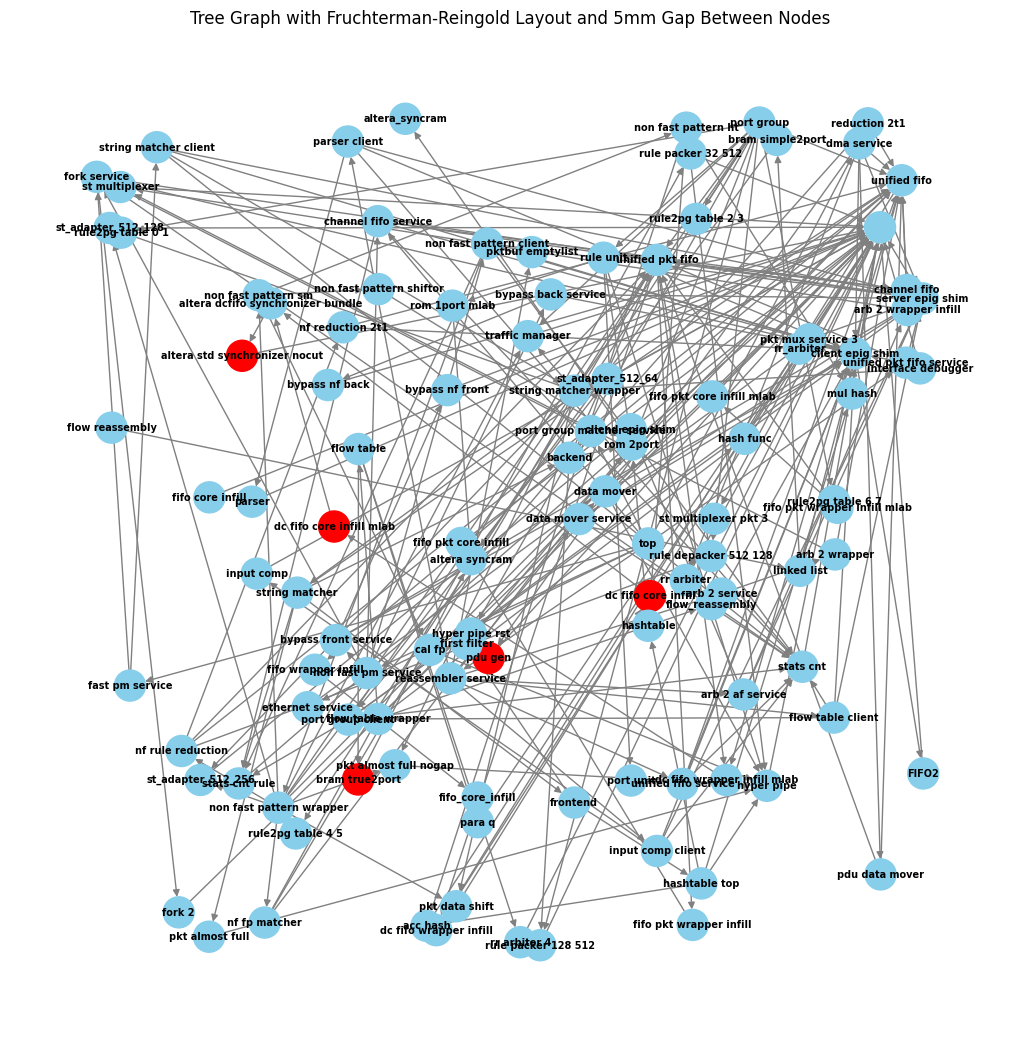

In [5]:
G = nx.DiGraph()
G.add_edges_from(edges)

# Position nodes using the Fruchterman-Reingold force-directed algorithm
pos = nx.random_layout(G)

# Convert 5mm to points (1 point = 1/72 inch, 1 inch = 25.4mm)
gap_mm = 150
gap_points = (gap_mm / 25.4) * 72

# Function to adjust node positions to maintain the minimum gap
def adjust_positions(pos, gap_points):
    adjusted_pos = {}
    for node, (x, y) in pos.items():
        adjusted_pos[node] = (x * gap_points, y * gap_points)
    return adjusted_pos

# Adjust positions to ensure the minimum gap
adjusted_pos = adjust_positions(pos, gap_points)

node_colors = []
error_bool = False
for node in G.nodes():
    for error in errors:
        if node == error:
            error_bool = True
            break
    if  error_bool:
        node_colors.append('red')
        error_bool = False
    else:
        node_colors.append('skyblue')
        error_bool = False
    # Draw the tree graph
plt.figure(figsize=(10, 10))
nx.draw(G, adjusted_pos, with_labels=True, node_size=500, node_color=node_colors, font_size=7, font_weight='bold', edge_color='gray')

# Display the plot
plt.title('Tree Graph with Fruchterman-Reingold Layout and 5mm Gap Between Nodes')
plt.show()



In [6]:
node_degrees = G.degree()  # This gives a DegreeView object with the degree of each node
max_degree_node = sorted(node_degrees, key=lambda x: x[1])
max_degree_node = max_degree_node[::-1]

print("Top 5 nodes highest degree nodes:", max_degree_node[0:6])

Top 5 nodes highest degree nodes: [('', 31), ('unified fifo', 18), ('client epig shim', 17), ('server epig shim', 16), ('unified pkt fifo', 14), ('port group', 13)]


In [7]:
target_node = 'unified fifo'
connected_nodes = list(G.predecessors(target_node))
print(f"Nodes connected to '{target_node}': {connected_nodes}")

connected_nodes = list(G.successors(target_node))
print(f"Nodes connected to '{target_node}': {connected_nodes}")

Nodes connected to 'unified fifo': ['dma service', 'unified fifo service', 'channel fifo', 'pdu data mover', 'flow table wrapper', 'arb 2 wrapper infill', 'arb 2 wrapper', 'string matcher wrapper', 'non fast pattern wrapper', 'string matcher', 'port group', 'nf rule reduction', 'linked list', 'nf reduction 2t1', 'reduction 2t1']
Nodes connected to 'unified fifo': ['dc fifo wrapper infill', 'dc fifo wrapper infill mlab', 'fifo wrapper infill']


In [51]:
num_nodes = G.number_of_nodes()
print("Number of nodes in the directed graph:", num_nodes)

Number of nodes in the directed graph: 114


In [69]:
node_degrees = G.degree()  # This gives a DegreeView object with the degree of each node
max_degree_node = sorted(node_degrees, key=lambda x: x[1])
print(max_degree_node)

[('st multiplexer pkt 3', 1), ('arb inorder ooo', 1), ('pktbuf emptylist', 1), ('cliend epig shim', 1), ('flow_reassembly', 1), ('fifo_core_infill', 1), ('flow reassembly', 1), ('rule2pg table 0 1', 1), ('rule2pg table 2 3', 1), ('rule2pg table 4 5', 1), ('rule2pg table 6 7', 1), ('fifo core infill', 1), ('altera_syncram', 1), ('rr_arbiter', 1), ('ethernet service', 2), ('pdu gen', 2), ('input comp', 2), ('parser', 2), ('data mover', 2), ('FIFO2', 2), ('fifo pkt wrapper infill', 2), ('fifo pkt wrapper infill mlab', 2), ('fork 2', 2), ('bypass nf front', 2), ('bypass nf back', 2), ('fifo wrapper infill', 2), ('hash func', 2), ('dc fifo core infill', 2), ('dc fifo core infill mlab', 2), ('fifo pkt core infill', 2), ('fifo pkt core infill mlab', 2), ('interface debugger', 2), ('bram true2port', 2), ('para q', 2), ('rr arbiter 4', 2), ('pkt almost full', 2), ('hyper pipe rst', 2), ('non fast pattern shiftor', 2), ('cal fp', 2), ('rule packer 32 512', 2), ('bram simple2port', 2), ('altera s

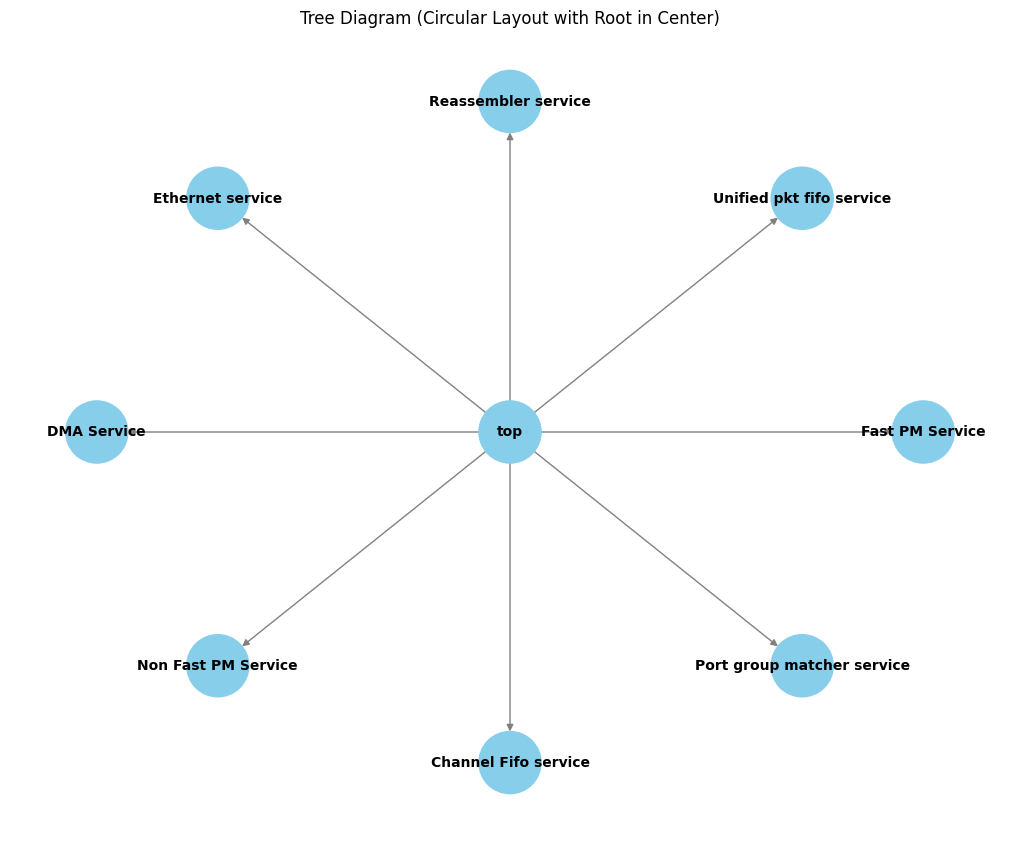

In [28]:
# Create a directed graph
G = nx.DiGraph()

# Add nodes and edges (child relationships)
edges = [
    ('top', 'DMA Service'),
    ('top', 'Non Fast PM Service'),
    ('top', 'Channel Fifo service'),
    ('top', 'Port group matcher service'),
    ('top', 'Fast PM Service'),
    ('top', 'Unified pkt fifo service'),
    ('top', 'Reassembler service'),
    ('top', 'Ethernet service')
]
G.add_edges_from(edges)

# Define the layout for the nodes
# Position the root node in the center and the children around it
layers = [
    ['top'], 
    ['DMA Service', 'Non Fast PM Service', 'Channel Fifo service','Port group matcher service', 'Fast PM Service', 'Unified pkt fifo service', 'Reassembler service', 'Ethernet service'],
]
pos = nx.shell_layout(G, nlist=layers)

# Define node colors, changing color for 'Child 2' and its descendants
node_colors = []
for node in G.nodes():
    if node == 'arb inorder ooo' or node == 'pktbuf emptylist':
        node_colors.append('red')
    else:
        node_colors.append('skyblue')

# Draw the nodes and edges
plt.figure(figsize=(10, 8))
nx.draw(G, pos, with_labels=True, node_size=2000, node_color=node_colors, font_size=10, font_weight="bold", edge_color="gray")

plt.title("Tree Diagram (Circular Layout with Root in Center)")
plt.show()



In [2]:
# Let's calculate the number of digits in the provided hexadecimal string.
hex_string = "1000020000000000abcdef000000080045000566000000004006a9e70a000001c0a8010204010400000000000000000050082000a0c80000fffffaa5f8fb2288ffff"
print(len(hex_string))



132
132
